# Phase 2: XGBoost and MLP Baselines

Train two supervised phishing classifiers on the twelve engineered features produced by Phase 1.

Strict boundary: `train.parquet` fits model parameters; `val.parquet` alone controls early stopping, calibration, threshold selection, and candidate selection. `test.parquet` and `adversarial_test.parquet` remain locked until the final evaluation section.

## 1. Environment

Install the two Phase 2 dependencies, then restart the kernel before continuing. This notebook pins the versions whose APIs were verified for this implementation.

In [1]:
%pip install -q xgboost==3.4.0 matplotlib==3.11.1

Note: you may need to restart the kernel to use updated packages.


In [2]:
import gc
import json
import os
import platform
import random
import sys
from copy import deepcopy
from datetime import datetime, timezone
from importlib.metadata import version as package_version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    try:
        torch.cuda.set_per_process_memory_fraction(0.55, 0)
    except RuntimeError as exc:
        print(f"CUDA memory cap was not applied: {exc}")

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print({
    "python": sys.version.split()[0],
    "torch": package_version("torch"),
    "xgboost": package_version("xgboost"),
})

{'python': '3.12.3', 'torch': '2.10.0a0+b558c986e8.nv25.11', 'xgboost': '3.4.0'}


## 2. Load and Validate Phase 1 Artifacts

The manifest controls feature order and expected counts. Loading holdouts here permits integrity checks only; model fitting and selection below use `train` and `val` exclusively.

In [3]:
PROJECT_DIR = Path("/workspace/training/email-classifier-nn")
DATA_DIR = PROJECT_DIR / "data" / "source-clean"
MANIFEST_PATH = DATA_DIR / "manifest.json"
SPLIT_PATHS = {
    "train": DATA_DIR / "train.parquet",
    "val": DATA_DIR / "val.parquet",
    "test": DATA_DIR / "test.parquet",
    "adversarial_test": DATA_DIR / "adversarial_test.parquet",
}

manifest = json.loads(MANIFEST_PATH.read_text())
PHASE1_FINGERPRINT = manifest["config_fingerprint"]
FEATURE_COLS = list(manifest["feature_columns"])
assert len(FEATURE_COLS) == 12

frames = {name: pd.read_parquet(path) for name, path in SPLIT_PATHS.items()}
for name, frame in frames.items():
    expected = manifest["counts"][name]
    assert len(frame) == expected["rows"], (name, len(frame), expected["rows"])
    assert int(frame["label"].sum()) == expected["phish"]
    assert int((frame["label"] == 0).sum()) == expected["legit"]
    assert int(frame["augmented"].sum()) == expected["augmented"]
    assert set(FEATURE_COLS).issubset(frame.columns)
    assert frame[FEATURE_COLS].notna().all().all()
    assert set(frame["label"].unique()).issubset({0, 1})

assert not frames["val"]["augmented"].any()
assert not frames["test"]["augmented"].any()
assert frames["adversarial_test"]["augmented"].all()
assert frames["adversarial_test"]["label"].eq(1).all()

X_train = frames["train"][FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = frames["train"]["label"].to_numpy(dtype=np.int64)
X_val = frames["val"][FEATURE_COLS].to_numpy(dtype=np.float32)
y_val = frames["val"]["label"].to_numpy(dtype=np.int64)

run_id = f"phase2-{PHASE1_FINGERPRINT[:16]}"
OUTPUT_DIR = PROJECT_DIR / "models" / run_id
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print({name: len(frame) for name, frame in frames.items()})
print("feature order:", FEATURE_COLS)
print("output:", OUTPUT_DIR)

{'train': 225225, 'val': 26414, 'test': 26414, 'adversarial_test': 13862}
feature order: ['f_body_len', 'f_subject_len', 'f_url_count', 'f_url_ip', 'f_url_at', 'f_upper_ratio', 'f_digit_ratio', 'f_exclaim', 'f_html_tags', 'f_susp_words', 'f_nonascii_ratio', 'f_zero_width']
output: /workspace/training/email-classifier-nn/models/phase2-a1e06b36c0af0662


In [4]:
def binary_metrics(y_true, probabilities, threshold):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    predictions = (probabilities >= threshold).astype(np.int64)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, predictions, zero_division=0)),
        "recall": float(recall_score(y_true, predictions, zero_division=0)),
        "f1": float(f1_score(y_true, predictions, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "average_precision": float(average_precision_score(y_true, probabilities)),
        "brier": float(brier_score_loss(y_true, probabilities)),
        "log_loss": float(log_loss(y_true, probabilities, labels=[0, 1])),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "specificity": float(tn / (tn + fp)) if tn + fp else None,
        "false_positive_rate": float(fp / (tn + fp)) if tn + fp else None,
    }


def adversarial_metrics(probabilities, threshold):
    probabilities = np.asarray(probabilities, dtype=np.float64)
    return {
        "threshold": float(threshold),
        "phishing_recall": float(np.mean(probabilities >= threshold)),
        "probability_mean": float(probabilities.mean()),
        "probability_median": float(np.median(probabilities)),
        "probability_min": float(probabilities.min()),
        "probability_max": float(probabilities.max()),
    }


def select_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    candidates = []
    for index, threshold in enumerate(thresholds):
        denominator = precision[index] + recall[index]
        score = 0.0 if denominator == 0 else 2 * precision[index] * recall[index] / denominator
        candidates.append((score, recall[index], -threshold, threshold))
    return float(max(candidates)[3])


def fit_sigmoid_calibrator(y_true, probabilities):
    clipped = np.clip(probabilities, 1e-7, 1 - 1e-7)
    logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    calibrator = LogisticRegression(random_state=SEED, solver="lbfgs")
    calibrator.fit(logits, y_true)
    return calibrator


def apply_calibrator(calibrator, probabilities):
    clipped = np.clip(probabilities, 1e-7, 1 - 1e-7)
    logits = np.log(clipped / (1 - clipped)).reshape(-1, 1)
    return calibrator.predict_proba(logits)[:, 1]


def atomic_json(payload, path):
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(json.dumps(payload, indent=2, sort_keys=True))
    os.replace(temporary, path)

## 3. GPU XGBoost Baseline

These are conservative baseline settings, not tuned hyperparameters. Early stopping observes only real validation log loss.

In [5]:
XGB_CONFIG = {
    "n_estimators": 2000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 2.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "tree_method": "hist",
    "device": "cuda",
    "early_stopping_rounds": 75,
    "random_state": SEED,
    "n_jobs": -1,
}

xgb_model = XGBClassifier(**XGB_CONFIG)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=50)
xgb_val_raw = xgb_model.predict_proba(X_val)[:, 1]
xgb_calibrator = fit_sigmoid_calibrator(y_val, xgb_val_raw)
xgb_val_probability = apply_calibrator(xgb_calibrator, xgb_val_raw)
xgb_threshold = select_threshold(y_val, xgb_val_probability)
xgb_validation = binary_metrics(y_val, xgb_val_probability, xgb_threshold)

xgb_model.save_model(OUTPUT_DIR / "xgboost.json")
joblib.dump(xgb_calibrator, OUTPUT_DIR / "xgboost_calibrator.joblib")
print("best_iteration:", xgb_model.best_iteration)
print(xgb_validation)

[0]	validation_0-logloss:0.68671
[50]	validation_0-logloss:0.53661
[100]	validation_0-logloss:0.50615
[150]	validation_0-logloss:0.49204
[200]	validation_0-logloss:0.48232
[250]	validation_0-logloss:0.47646
[300]	validation_0-logloss:0.47156
[350]	validation_0-logloss:0.46591
[400]	validation_0-logloss:0.46241
[450]	validation_0-logloss:0.45913
[500]	validation_0-logloss:0.45657
[550]	validation_0-logloss:0.45387
[600]	validation_0-logloss:0.45166
[650]	validation_0-logloss:0.44996
[700]	validation_0-logloss:0.44827
[750]	validation_0-logloss:0.44642
[800]	validation_0-logloss:0.44508
[850]	validation_0-logloss:0.44362
[900]	validation_0-logloss:0.44252
[950]	validation_0-logloss:0.44124
[1000]	validation_0-logloss:0.44015
[1050]	validation_0-logloss:0.43903
[1100]	validation_0-logloss:0.43828
[1150]	validation_0-logloss:0.43738
[1200]	validation_0-logloss:0.43646
[1250]	validation_0-logloss:0.43568
[1300]	validation_0-logloss:0.43469
[1350]	validation_0-logloss:0.43397
[1400]	validati

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:569: UserWarning: [12:47:52] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


best_iteration: 1998
{'threshold': 0.3881972078928728, 'precision': 0.7831373866308364, 'recall': 0.8423296480959607, 'f1': 0.8116557582509399, 'roc_auc': 0.8829073539110737, 'average_precision': 0.9055589497198815, 'brier': 0.13724837574788853, 'log_loss': 0.422831053779733, 'tn': 9347, 'fp': 3228, 'fn': 2182, 'tp': 11657, 'specificity': 0.743300198807157, 'false_positive_rate': 0.25669980119284297}


## 4. Small PyTorch MLP Baseline

The scaler is fitted on training features only. The MLP uses explicit real-validation loss early stopping and restores the best state before calibration.

In [6]:
MLP_CONFIG = {
    "hidden_dims": [64, 32],
    "dropout": 0.15,
    "batch_size": 4096,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 200,
    "patience": 20,
    "min_delta": 1e-5,
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)

class FeatureMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super().__init__()
        layers = []
        previous = input_dim
        for hidden in hidden_dims:
            layers.extend([nn.Linear(previous, hidden), nn.ReLU(), nn.Dropout(dropout)])
            previous = hidden
        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features).squeeze(1)


def predict_mlp(model, features, batch_size, device, use_bf16):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(features)),
        batch_size=batch_size,
        shuffle=False,
        pin_memory=False,
    )
    outputs = []
    model.eval()
    with torch.inference_mode():
        for (batch_features,) in loader:
            batch_features = batch_features.to(device)
            with torch.autocast(
                device_type=device.type, dtype=torch.bfloat16, enabled=use_bf16
            ):
                logits = model(batch_features)
            outputs.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(outputs)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_bf16 = device.type == "cuda" and torch.cuda.is_bf16_supported()
mlp_model = FeatureMLP(len(FEATURE_COLS), MLP_CONFIG["hidden_dims"], MLP_CONFIG["dropout"]).to(device)
optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=MLP_CONFIG["learning_rate"],
    weight_decay=MLP_CONFIG["weight_decay"],
)
positive_weight = float((y_train == 0).sum() / (y_train == 1).sum())
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(positive_weight, device=device))
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_scaled), torch.from_numpy(y_train.astype(np.float32))),
    batch_size=MLP_CONFIG["batch_size"],
    shuffle=True,
    generator=generator,
    pin_memory=False,
)

best_loss = float("inf")
best_state = None
best_epoch = 0
stale_epochs = 0
history = []
for epoch in range(1, MLP_CONFIG["max_epochs"] + 1):
    mlp_model.train()
    train_loss_total = 0.0
    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16, enabled=use_bf16):
            logits = mlp_model(batch_features)
            loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        train_loss_total += loss.item() * len(batch_labels)

    val_raw = predict_mlp(
        mlp_model, X_val_scaled, MLP_CONFIG["batch_size"], device, use_bf16
    )
    validation_loss = log_loss(y_val, val_raw, labels=[0, 1])
    history.append({
        "epoch": epoch,
        "train_loss": train_loss_total / len(y_train),
        "validation_log_loss": float(validation_loss),
    })
    print(history[-1])

    if validation_loss < best_loss - MLP_CONFIG["min_delta"]:
        best_loss = float(validation_loss)
        best_epoch = epoch
        best_state = deepcopy({key: value.detach().cpu() for key, value in mlp_model.state_dict().items()})
        stale_epochs = 0
    else:
        stale_epochs += 1

    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()
    if stale_epochs >= MLP_CONFIG["patience"]:
        break

assert best_state is not None
mlp_model.load_state_dict(best_state)
mlp_model.to(device)
mlp_val_raw = predict_mlp(mlp_model, X_val_scaled, MLP_CONFIG["batch_size"], device, use_bf16)
mlp_calibrator = fit_sigmoid_calibrator(y_val, mlp_val_raw)
mlp_val_probability = apply_calibrator(mlp_calibrator, mlp_val_raw)
mlp_threshold = select_threshold(y_val, mlp_val_probability)
mlp_validation = binary_metrics(y_val, mlp_val_probability, mlp_threshold)

model_tmp = OUTPUT_DIR / "mlp_state.pt.tmp"
torch.save(best_state, model_tmp)
os.replace(model_tmp, OUTPUT_DIR / "mlp_state.pt")
joblib.dump(scaler, OUTPUT_DIR / "mlp_scaler.joblib")
joblib.dump(mlp_calibrator, OUTPUT_DIR / "mlp_calibrator.joblib")
print({"device": str(device), "bf16": use_bf16, "best_epoch": best_epoch})
print(mlp_validation)

{'epoch': 1, 'train_loss': 0.6933477530811296, 'validation_log_loss': 0.6531380573755968}
{'epoch': 2, 'train_loss': 0.6144850711860089, 'validation_log_loss': 0.5943542552635416}
{'epoch': 3, 'train_loss': 0.5745833382721363, 'validation_log_loss': 0.5777093819540128}
{'epoch': 4, 'train_loss': 0.5578555398898274, 'validation_log_loss': 0.5696778909398437}
{'epoch': 5, 'train_loss': 0.5479106064315958, 'validation_log_loss': 0.5629843052022658}
{'epoch': 6, 'train_loss': 0.5414226661258803, 'validation_log_loss': 0.5619091887574436}
{'epoch': 7, 'train_loss': 0.5354127726196012, 'validation_log_loss': 0.5586654319539435}
{'epoch': 8, 'train_loss': 0.5319717558889254, 'validation_log_loss': 0.5568572989057355}
{'epoch': 9, 'train_loss': 0.5259007288478352, 'validation_log_loss': 0.5495548052601915}
{'epoch': 10, 'train_loss': 0.5220093301332597, 'validation_log_loss': 0.5498214458219473}
{'epoch': 11, 'train_loss': 0.517655552202886, 'validation_log_loss': 0.5466886332140302}
{'epoch':

## 5. Validation-Only Calibration, Thresholds, and Selection

Both calibrators and thresholds were fitted from validation predictions only. Candidate selection is deterministic: higher validation F1, then higher phishing recall, then lower false-positive rate.

         threshold  precision    recall        f1   roc_auc  \
xgboost   0.388197   0.783137  0.842330  0.811656  0.882907   
mlp       0.431570   0.766464  0.782137  0.774221  0.840274   

         average_precision     brier  log_loss      tn      fp      fn  \
xgboost           0.905559  0.137248  0.422831  9347.0  3228.0  2182.0   
mlp               0.868939  0.161073  0.487287  9277.0  3298.0  3015.0   

              tp  specificity  false_positive_rate  
xgboost  11657.0     0.743300             0.256700  
mlp      10824.0     0.737734             0.262266  
chosen model: xgboost


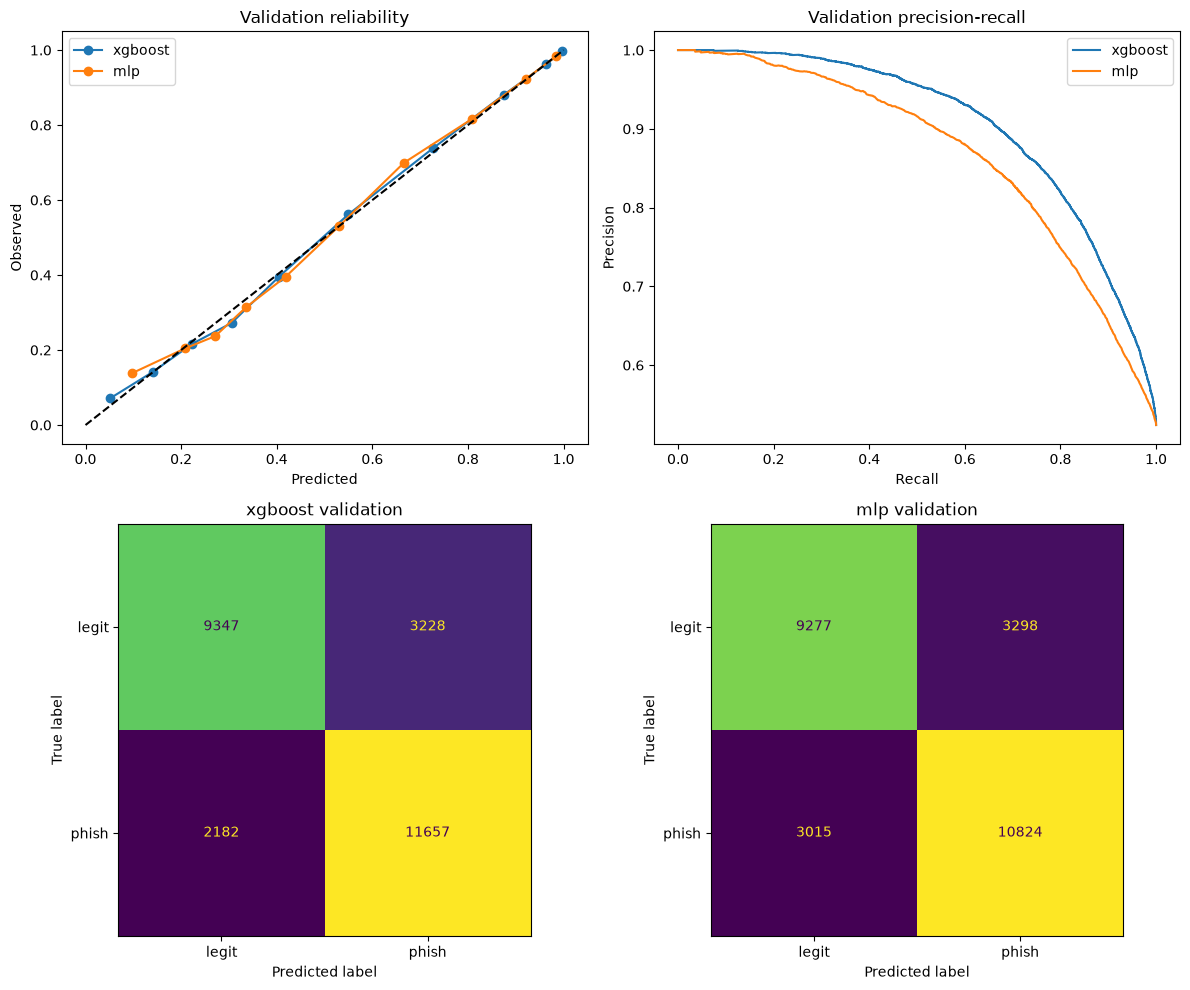

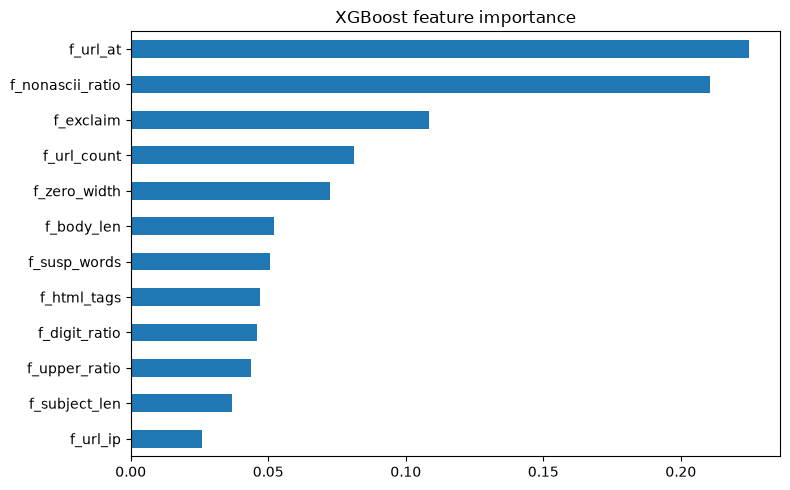

In [7]:
validation_probabilities = {
    "xgboost": xgb_val_probability,
    "mlp": mlp_val_probability,
}
validation_metrics = {
    "xgboost": xgb_validation,
    "mlp": mlp_validation,
}
thresholds = {
    "xgboost": xgb_threshold,
    "mlp": mlp_threshold,
}

def selection_key(model_name):
    metrics = validation_metrics[model_name]
    return (metrics["f1"], metrics["recall"], -metrics["false_positive_rate"])

chosen_model = max(sorted(validation_metrics), key=selection_key)
print(pd.DataFrame(validation_metrics).T)
print("chosen model:", chosen_model)

figure, axes = plt.subplots(2, 2, figsize=(12, 10))
for name, probabilities in validation_probabilities.items():
    observed, predicted = calibration_curve(y_val, probabilities, n_bins=10, strategy="quantile")
    axes[0, 0].plot(predicted, observed, marker="o", label=name)
    precision, recall, _ = precision_recall_curve(y_val, probabilities)
    axes[0, 1].plot(recall, precision, label=name)
axes[0, 0].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[0, 0].set(title="Validation reliability", xlabel="Predicted", ylabel="Observed")
axes[0, 1].set(title="Validation precision-recall", xlabel="Recall", ylabel="Precision")
axes[0, 0].legend()
axes[0, 1].legend()
for axis, name in zip(axes[1], ("xgboost", "mlp")):
    predictions = (validation_probabilities[name] >= thresholds[name]).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_val, predictions, labels=[0, 1], display_labels=["legit", "phish"],
        colorbar=False, ax=axis,
    )
    axis.set_title(f"{name} validation")
figure.tight_layout()
figure.savefig(str(OUTPUT_DIR / "validation_diagnostics.png"), dpi=160)
plt.show()

importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
importance.plot.barh(figsize=(8, 5), title="XGBoost feature importance")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "xgboost_feature_importance.png"), dpi=160)
plt.show()

## 6. Final Locked Evaluation and Artifact Manifest

Model choice, calibrators, and thresholds are now frozen. This is the first section that uses holdout feature values for prediction. The real test measures complete binary-classification performance; the all-positive adversarial set reports phishing recall and probability summaries only.

In [8]:
X_test = frames["test"][FEATURE_COLS].to_numpy(dtype=np.float32)
y_test = frames["test"]["label"].to_numpy(dtype=np.int64)
X_adversarial = frames["adversarial_test"][FEATURE_COLS].to_numpy(dtype=np.float32)

xgb_test_probability = apply_calibrator(
    xgb_calibrator, xgb_model.predict_proba(X_test)[:, 1]
)
xgb_adversarial_probability = apply_calibrator(
    xgb_calibrator, xgb_model.predict_proba(X_adversarial)[:, 1]
)

X_test_scaled = scaler.transform(X_test).astype(np.float32)
X_adversarial_scaled = scaler.transform(X_adversarial).astype(np.float32)
mlp_test_probability = apply_calibrator(
    mlp_calibrator,
    predict_mlp(mlp_model, X_test_scaled, MLP_CONFIG["batch_size"], device, use_bf16),
)
mlp_adversarial_probability = apply_calibrator(
    mlp_calibrator,
    predict_mlp(mlp_model, X_adversarial_scaled, MLP_CONFIG["batch_size"], device, use_bf16),
)

final_metrics = {
    "validation": validation_metrics,
    "test": {
        "xgboost": binary_metrics(y_test, xgb_test_probability, xgb_threshold),
        "mlp": binary_metrics(y_test, mlp_test_probability, mlp_threshold),
    },
    "adversarial_test": {
        "xgboost": adversarial_metrics(xgb_adversarial_probability, xgb_threshold),
        "mlp": adversarial_metrics(mlp_adversarial_probability, mlp_threshold),
    },
}

package_versions = {
    "python": platform.python_version(),
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scikit_learn": package_version("scikit-learn"),
    "torch": package_version("torch"),
    "xgboost": package_version("xgboost"),
    "matplotlib": package_version("matplotlib"),
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
run_manifest = {
    "run_id": run_id,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "phase1_config_fingerprint": PHASE1_FINGERPRINT,
    "phase1_manifest": str(MANIFEST_PATH),
    "source_files": {name: str(path) for name, path in SPLIT_PATHS.items()},
    "source_counts": manifest["counts"],
    "feature_columns": FEATURE_COLS,
    "chosen_model": chosen_model,
    "selection_data": "val.parquet only",
    "selection_criteria": ["higher_f1", "higher_recall", "lower_false_positive_rate"],
    "holdout_policy": "test and adversarial_test opened for prediction only after selection",
}

atomic_json(thresholds, OUTPUT_DIR / "thresholds.json")
atomic_json(final_metrics, OUTPUT_DIR / "metrics.json")
atomic_json(
    {"seed": SEED, "xgboost": XGB_CONFIG, "mlp": MLP_CONFIG, "mlp_best_epoch": best_epoch},
    OUTPUT_DIR / "config.json",
)
atomic_json(FEATURE_COLS, OUTPUT_DIR / "feature_columns.json")
atomic_json(package_versions, OUTPUT_DIR / "package_versions.json")
atomic_json(run_manifest, OUTPUT_DIR / "run_manifest.json")

print("FINAL REAL TEST")
print(pd.DataFrame(final_metrics["test"]).T)
print("FINAL ADVERSARIAL TEST")
print(pd.DataFrame(final_metrics["adversarial_test"]).T)
print("selected:", chosen_model)
print("artifacts:", OUTPUT_DIR)

FINAL REAL TEST
         threshold  precision    recall        f1   roc_auc  \
xgboost   0.388197   0.779030  0.837758  0.807327  0.881327   
mlp       0.431570   0.763178  0.784375  0.773631  0.840187   

         average_precision     brier  log_loss      tn      fp      fn  \
xgboost           0.905008  0.138361  0.424041  9258.0  3294.0  2249.0   
mlp               0.868965  0.161046  0.486660  9178.0  3374.0  2989.0   

              tp  specificity  false_positive_rate  
xgboost  11613.0     0.737572             0.262428  
mlp      10873.0     0.731198             0.268802  
FINAL ADVERSARIAL TEST
         threshold  phishing_recall  probability_mean  probability_median  \
xgboost   0.388197         0.999856          0.998049            0.999824   
mlp       0.431570         0.999856          0.995762            0.999030   

         probability_min  probability_max  
xgboost         0.172931              1.0  
mlp             0.202477              1.0  
selected: xgboost
artifac